# Validation Metrics

This section evaluates the model using traditional classification metrics.

We report:
- Validation loss
- Top-1 accuracy
- Top-3 accuracy
- Top-5 accuracy

These metrics provide a baseline comparison with previous supervised learning approaches.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [3]:
import torch

from torch.utils.data import DataLoader

from tqdm import tqdm

import sqlite3

import json

import gzip

import pandas as pd

In [4]:
from src.data.tokenizer import MahjongTokenizer

from src.features.tensorization import Tensorizer

from src.data.dataset import MahjongDataset

from src.data.collator import MahjongCollator

from src.models.transformer_model import (
    MahjongTransformer
)

from src.training.metrics import (
    compute_topk_accuracy,
)

from src.utils.tile_decoder import (
    tile136_to_string,
)

from src.utils.action_decoder import (
    decode_action,
)

from src.analysis.ukeire import (
    evaluate_discards_ukeire,
)

from src.analysis.error_analysis import (
    categorize_mistake,
)

In [5]:
tokenizer = MahjongTokenizer()

tensorizer = Tensorizer()

collator = MahjongCollator()

In [6]:
val_dataset = MahjongDataset(

    db_path="../data/discard/strategic.db",

    limit=500000,
)

print(len(val_dataset))

500000


In [7]:
val_loader = DataLoader(

    val_dataset,

    batch_size=64,

    shuffle=False,

    collate_fn=collator.collate,

    num_workers=4,

    pin_memory=True,

    persistent_workers=True,
)

In [8]:
model = MahjongTransformer()

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
checkpoint = torch.load(

    "../checkpoints/strategic_500k/epoch_8.pt",

    map_location=device,
)

/home/julia/miniforge3/envs/riichi-ai/lib/python3.11/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_89 sm_90 compute_90.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [11]:
model.load_state_dict(
    checkpoint["model_state_dict"]
)

<All keys matched successfully>

In [12]:
model.to(device)

model.eval()

print("Checkpoint loaded.")

Checkpoint loaded.


In [13]:
criterion = torch.nn.CrossEntropyLoss()

total_loss = 0

total_correct = 0

total_samples = 0

In [14]:
with torch.no_grad():

    for batch in tqdm(val_loader):

        batch = {

            k: v.to(device)
            if isinstance(v, torch.Tensor)
            else v

            for k, v in batch.items()
        }

        targets = batch["target"]

        logits_list = model(batch)

        batch_loss = 0

        for logits, target in zip(
            logits_list,
            targets,
        ):

            target = target.unsqueeze(0)

            logits = logits.unsqueeze(0)

            loss = criterion(
                logits,
                target,
            )

            batch_loss += loss.item()

            prediction = torch.argmax(
                logits,
                dim=1,
            )

            total_correct += (
                prediction == target
            ).sum().item()

            total_samples += 1

        total_loss += batch_loss

  0%|          | 0/7813 [00:00<?, ?it/s]/home/julia/miniforge3/envs/riichi-ai/lib/python3.11/site-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1739474893324/work/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
100%|██████████| 7813/7813 [1:07:47<00:00,  1.92it/s]


In [15]:
val_loss = total_loss / len(val_loader)

val_accuracy = total_correct / total_samples

print(f"Validation Loss: {val_loss:.4f}")

print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Loss: 59.4591
Validation Accuracy: 0.6635


In [16]:
top3_correct = 0

top3_total = 0

with torch.no_grad():

    for batch in tqdm(val_loader):

        batch = {

            k: v.to(device)
            if isinstance(v, torch.Tensor)
            else v

            for k, v in batch.items()
        }

        targets = batch["target"]

        logits_list = model(batch)

        top3_correct += compute_topk_accuracy(

            logits_list,

            targets,

            k=3,
        )

        top3_total += len(targets)

top3 = top3_correct / top3_total

print(f"Top-3 Accuracy: {top3:.4f}")

  0%|          | 0/7813 [00:00<?, ?it/s]

100%|██████████| 7813/7813 [1:02:39<00:00,  2.08it/s]

Top-3 Accuracy: 0.0145


In [17]:
top5_correct = 0

top5_total = 0

with torch.no_grad():

    for batch in tqdm(val_loader):

        batch = {

            k: v.to(device)
            if isinstance(v, torch.Tensor)
            else v

            for k, v in batch.items()
        }

        targets = batch["target"]

        logits_list = model(batch)

        top5_correct += compute_topk_accuracy(

            logits_list,

            targets,

            k=5,
        )

        top5_total += len(targets)

top5 = top5_correct / top5_total

print(f"Top-5 Accuracy: {top5:.4f}")

100%|██████████| 7813/7813 [59:59<00:00,  2.17it/s]

Top-5 Accuracy: 0.0153


# Strategic Evaluation

Exact action matching is insufficient for Mahjong because multiple discards can produce equivalent strategic outcomes.

To address this, we evaluate:
- Shanten preservation
- Effective ukeire
- Strategic mistake categories

In [18]:
conn = sqlite3.connect(
    "../data/discard/strategic.db"
)

In [71]:
results = []

In [72]:
NUM_SAMPLES = 10000

In [73]:
row_result = {}
for offset in tqdm(range(NUM_SAMPLES)):

    query = f"""
    SELECT Data
    FROM Discard
    LIMIT 1 OFFSET {offset}
    """

    row = conn.execute(
        query
    ).fetchone()

    decoded = json.loads(
        gzip.decompress(row[0])
    )

    row_result["offset"] = offset

    canonical_state = {

    "round_wind":
        decoded["round_wind"],

    "num_honba":
        decoded["num_honba"],

    "num_riichi":
        decoded["num_riichi"],

    "player_wind":
        decoded["player_wind"],

    "position":
        decoded["position"],

    "remain_tiles":
        decoded["remain_tiles"],

    "dora_indicators":
        decoded["dora_indicators"],

    "hand_tiles":
        decoded["hand_tiles"],

    "players": {

        "0": decoded["0"],
        "1": decoded["1"],
        "2": decoded["2"],
        "3": decoded["3"],
    },

    "valid_actions":
        decoded["valid_actions"],

    "action_idx":
        decoded["action_idx"],
    }

    tokens = tokenizer.tokenize(
        canonical_state
    )

    tensor_dict = tensorizer.tensorize(
        tokens
    )

    batch = collator.collate(
        [tensor_dict]
    )

    batch = {

        k: v.to(device)
        if isinstance(v, torch.Tensor)
        else v

        for k, v in batch.items()
    }

    with torch.no_grad():

        logits = model(batch)[0]

    probabilities = torch.softmax(
        logits,
        dim=0,
    )

    prediction = torch.argmax(
        probabilities
    ).item()

    expert_action = decoded[
        "valid_actions"
    ][
        decoded["action_idx"]
    ]

    model_action = decoded[
        "valid_actions"
    ][prediction]

    if expert_action["type"] != 1:
        continue

    if model_action["type"] != 1:
        continue

    expert_tile = expert_action[
        "tiles"
    ][0]

    model_tile = model_action[
        "tiles"
    ][0]

    discard_eval = evaluate_discards_ukeire(
        canonical_state
    )

    discard_lookup = {}

    for r in discard_eval:

        discard_lookup[
            r["discard"]
        ] = r

    expert_metrics = discard_lookup[
        expert_tile
    ]

    model_metrics = discard_lookup[
        model_tile
    ]

    row_result = {

    "expert_tile":
        tile136_to_string(
            expert_tile
        ),

    "model_tile":
        tile136_to_string(
            model_tile
        ),

    "same_action":
        expert_tile == model_tile,

    "expert_shanten":
        expert_metrics["shanten"],

    "model_shanten":
        model_metrics["shanten"],

    "expert_ukeire":
        expert_metrics["ukeire"],

    "model_ukeire":
        model_metrics["ukeire"],

    "shanten_difference":
        (
            expert_metrics["shanten"]
            -
            model_metrics["shanten"]
        ),

    "ukeire_difference":
        (
            expert_metrics["ukeire"]
            -
            model_metrics["ukeire"]
        ),

    "model_prob":
        probabilities[
            prediction
        ].item(),
    }

    row_result["category"] = (
        categorize_mistake(
            row_result
        )
    )

    results.append(
        row_result
    )

100%|██████████| 10000/10000 [02:06<00:00, 79.07it/s]


In [74]:
results_df = pd.DataFrame(
    results
)

results_df.head()

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
0,east,west,False,4,4,66,67,0,-1,0.553254,near_equivalent,1.0
1,red,west,False,4,4,71,72,0,-1,0.715873,near_equivalent,2.0
2,west,west,True,3,3,32,32,0,0,0.473912,exact_match,3.0
3,south,south,True,3,3,52,52,0,0,0.691649,exact_match,4.0
4,2m,2m,True,3,3,54,54,0,0,0.612358,exact_match,5.0


In [75]:
results_df.groupby("category").size()

category
better_shanten      327
better_ukeire       576
equivalent         1239
exact_match        6657
near_equivalent     583
shanten_loss        181
ukeire_loss         437
dtype: int64

In [76]:
results_df.groupby("category")[

    [
        "shanten_difference",
        "ukeire_difference",
    ]

].mean()

,shanten_difference,ukeire_difference
category,,
better_shanten,1.0,25.519878
better_ukeire,0.0,-8.756944
equivalent,0.0,0.000000
exact_match,0.0,0.000000
near_equivalent,0.0,-0.305317
shanten_loss,-1.0,-25.911602
ukeire_loss,0.0,6.794050


In [77]:
summary = pd.DataFrame({

    "Metric": [

        "Exact Accuracy",
        "Strategic Accuracy",
        "Mean Ukeire Difference",
    ],

    "Value": [

        results_df["same_action"].mean(),

        results_df["category"].isin([
            "exact_match",
            "equivalent",
            "near_equivalent",
        ]).mean(),

        results_df["ukeire_difference"].mean(),
    ]
})

summary

,Metric,Value
0,Exact Accuracy,0.6657
1,Strategic Accuracy,0.8479
2,Mean Ukeire Difference,0.1402


In [78]:
distribution = (

    results_df["category"]

    .value_counts(normalize=True)
)

distribution

category
exact_match        0.6657
equivalent         0.1239
near_equivalent    0.0583
better_ukeire      0.0576
ukeire_loss        0.0437
better_shanten     0.0327
shanten_loss       0.0181
Name: proportion, dtype: float64

In [79]:
results_df[
    "ukeire_difference"
].mean()

np.float64(0.1402)

In [80]:
results_df[
    "same_action"
].mean()

np.float64(0.6657)

In [81]:
worst = results_df[

    results_df["category"].isin([
        "catastrophic",
        "shanten_loss",
        "ukeire_loss",
    ])
]

worst = worst.sort_values(

    by=[
        "category",
        "ukeire_difference",
    ],

    ascending=[
        True,
        False,
    ],
)

worst.head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
1837,9s,1s,False,1,2,6,6,-1,0,0.714325,shanten_loss,1838.0
3355,white,2m,False,1,2,7,7,-1,0,0.375369,shanten_loss,3356.0
9125,6p,8p,False,1,2,5,5,-1,0,0.664047,shanten_loss,9126.0
9412,east,9p,False,1,2,5,5,-1,0,0.592128,shanten_loss,9413.0
9413,3p,9p,False,1,2,5,5,-1,0,0.246795,shanten_loss,9414.0
6090,5m,8p,False,1,2,15,16,-1,-1,0.361680,shanten_loss,6091.0
8381,7p,9m,False,1,2,10,11,-1,-1,0.429293,shanten_loss,8382.0
8914,9m,1s,False,1,2,7,8,-1,-1,0.294074,shanten_loss,8915.0
9404,5p,1s,False,2,3,11,12,-1,-1,0.453433,shanten_loss,9405.0
4971,2m,1m,False,1,2,7,9,-1,-2,0.433541,shanten_loss,4972.0


In [82]:
best = results_df[

    results_df["category"].isin([
        "better_shanten",
        "better_ukeire",
        "near_equivalent",
        "equivalent",
    ])
]

best = best.sort_values(

    by=[
        "category",
        "ukeire_difference",
    ],

    ascending=[
        True,
        True,
    ],
)

best.head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
227,6p,1s,False,2,1,12,12,1,0,0.820386,better_shanten,228.0
1744,1s,7m,False,1,0,3,3,1,0,0.791497,better_shanten,1745.0
789,south,white,False,4,3,70,69,1,1,0.448554,better_shanten,790.0
1263,6m,north,False,3,2,46,45,1,1,0.637709,better_shanten,1264.0
1840,south,3s,False,2,1,6,5,1,1,0.294739,better_shanten,1841.0
1841,9s,5p,False,3,2,7,6,1,1,0.618246,better_shanten,1842.0
2190,8s,west,False,3,2,14,13,1,1,0.698695,better_shanten,2191.0
2635,9s,6m,False,3,2,13,12,1,1,0.765175,better_shanten,2636.0
4975,4s,1m,False,2,1,8,7,1,1,0.829366,better_shanten,4976.0
9266,2s,east,False,4,3,41,40,1,1,0.483391,better_shanten,9267.0


In [83]:
model_better = results_df[
    results_df["category"].isin([
        "better_shanten",
        "better_ukeire",
    ])
]

model_better.head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
38,9s,5p,False,2,1,42,10,1,32,0.692941,better_shanten,39.0
39,1p,8s,False,2,1,35,12,1,23,0.568940,better_shanten,40.0
80,7m,1s,False,3,3,23,42,0,-19,0.655636,better_ukeire,81.0
89,1p,7p,False,2,2,12,16,0,-4,0.600419,better_ukeire,90.0
91,9m,7p,False,2,2,15,19,0,-4,0.762736,better_ukeire,92.0
93,3p,7p,False,2,2,25,32,0,-7,0.849646,better_ukeire,94.0
95,green,2p,False,3,2,60,25,1,35,0.515771,better_shanten,96.0
99,5s,north,False,3,3,53,69,0,-16,0.420074,better_ukeire,100.0
105,9m,north,False,3,3,64,72,0,-8,0.730801,better_ukeire,106.0
111,1p,south,False,4,4,70,78,0,-8,0.427598,better_ukeire,112.0


In [84]:
high_confidence_mistakes = results_df[

    results_df["same_action"] == False
]

high_confidence_mistakes = high_confidence_mistakes.sort_values(

    by="model_prob",

    ascending=False,
)

high_confidence_mistakes.head(20)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
7223,3m,8m,False,1,1,12,26,0,-14,0.997149,better_ukeire,7224.0
4788,6s,1p,False,1,1,11,15,0,-4,0.994907,better_ukeire,4789.0
7217,7p,1p,False,1,1,15,15,0,0,0.989373,equivalent,7218.0
6193,4s,white,False,1,0,21,8,1,13,0.987052,better_shanten,6194.0
2212,4m,8m,False,1,1,7,22,0,-15,0.987027,better_ukeire,2213.0
4406,1s,3p,False,1,0,11,7,1,4,0.985884,better_shanten,4407.0
9481,7s,5s,False,0,0,4,4,0,0,0.985609,equivalent,9482.0
2961,green,1s,False,3,2,61,24,1,37,0.985241,better_shanten,2962.0
7321,7p,1s,False,1,1,14,27,0,-13,0.982286,better_ukeire,7322.0
6947,5s,9m,False,0,0,2,4,0,-2,0.979381,near_equivalent,6948.0


In [85]:
results_df["category"].value_counts()

category
exact_match        6657
equivalent         1239
near_equivalent     583
better_ukeire       576
ukeire_loss         437
better_shanten      327
shanten_loss        181
Name: count, dtype: int64

In [86]:
results_df.to_csv(

    "../reports/500k/strategic_validation_analysis_500k.csv",

    index=False,
)

print("Saved.")

Saved.


In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

In [88]:
sns.set_theme(style="whitegrid")

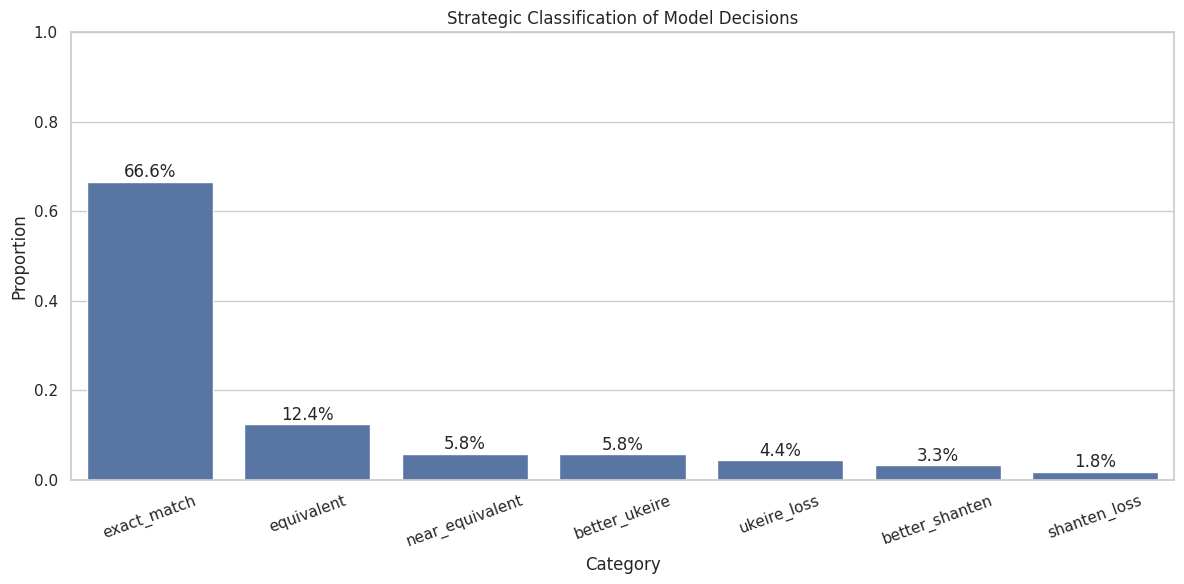

In [89]:
plt.figure(figsize=(12, 6))

sns.barplot(

    x=distribution.index,

    y=distribution.values,
)

plt.ylabel("Proportion")

plt.xlabel("Category")

plt.title(
    "Strategic Classification of Model Decisions"
)

plt.xticks(rotation=20)

plt.ylim(0, 1)

for i, value in enumerate(
    distribution.values
):

    plt.text(

        i,

        value + 0.01,

        f"{value:.1%}",

        ha="center",
    )

plt.tight_layout()

plt.show()

In [90]:
plt.savefig(

    "../reports/figures/500k/category_distribution_500k.png",

    dpi=300,

    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>

In [91]:
exact_accuracy = (
    results_df["same_action"]
    .mean()
)

strategic_accuracy = (

    results_df["category"]

    .isin([
        "exact_match",
        "equivalent",
        "near_equivalent",
        "better_ukeire",
        "better_shanten",
    ])

    .mean()
)

comparison_df = pd.DataFrame({

    "Metric": [

        "Exact Accuracy",

        "Strategic Accuracy",
    ],

    "Value": [

        exact_accuracy,

        strategic_accuracy,
    ]
})

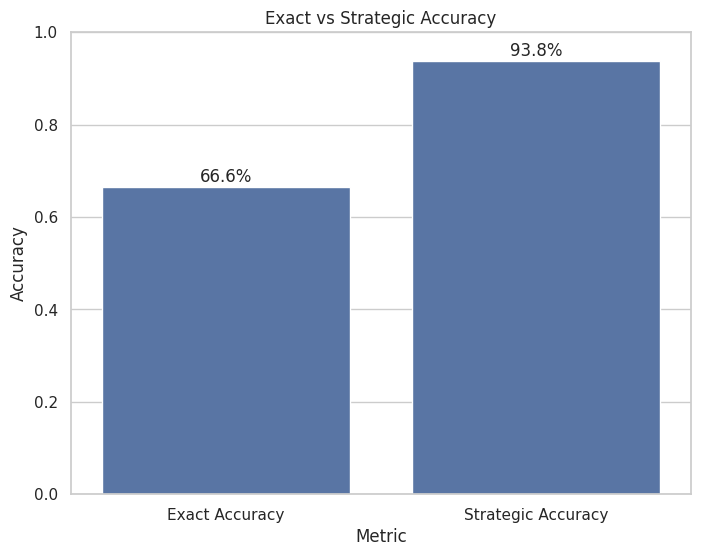

In [92]:
plt.figure(figsize=(8, 6))

sns.barplot(

    data=comparison_df,

    x="Metric",

    y="Value",
)

plt.ylim(0, 1)

plt.ylabel("Accuracy")

plt.title(
    "Exact vs Strategic Accuracy"
)

for i, value in enumerate(
    comparison_df["Value"]
):

    plt.text(

        i,

        value + 0.01,

        f"{value:.1%}",

        ha="center",
    )

plt.show()

In [93]:
plt.savefig(

    "../reports/figures/500k/accuracy_difference_500k.png",

    dpi=300,

    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>

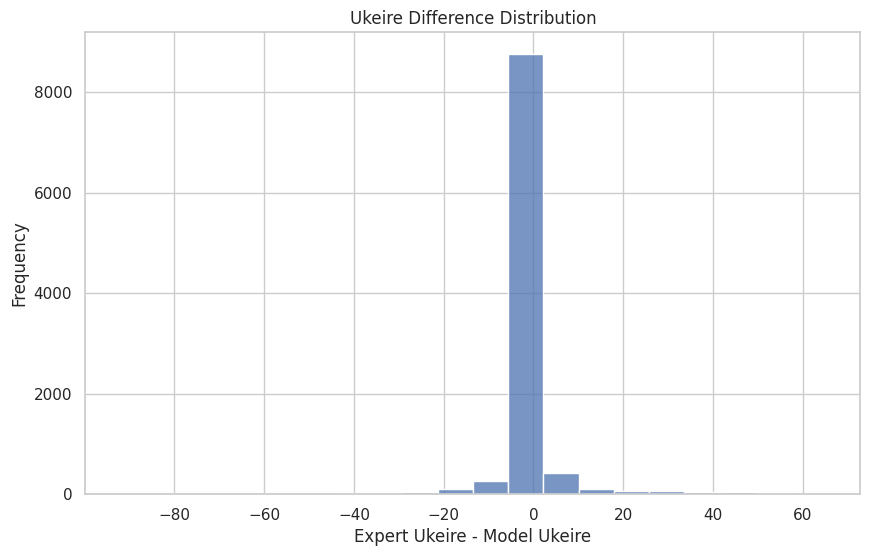

In [94]:
plt.figure(figsize=(10, 6))

sns.histplot(

    results_df["ukeire_difference"],

    bins=20,
)

plt.xlabel(
    "Expert Ukeire - Model Ukeire"
)

plt.ylabel("Frequency")

plt.title(
    "Ukeire Difference Distribution"
)

plt.show()

In [95]:
plt.savefig(

    "../reports/figures/500k/ukeire_distribution_500k.png",

    dpi=300,

    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>

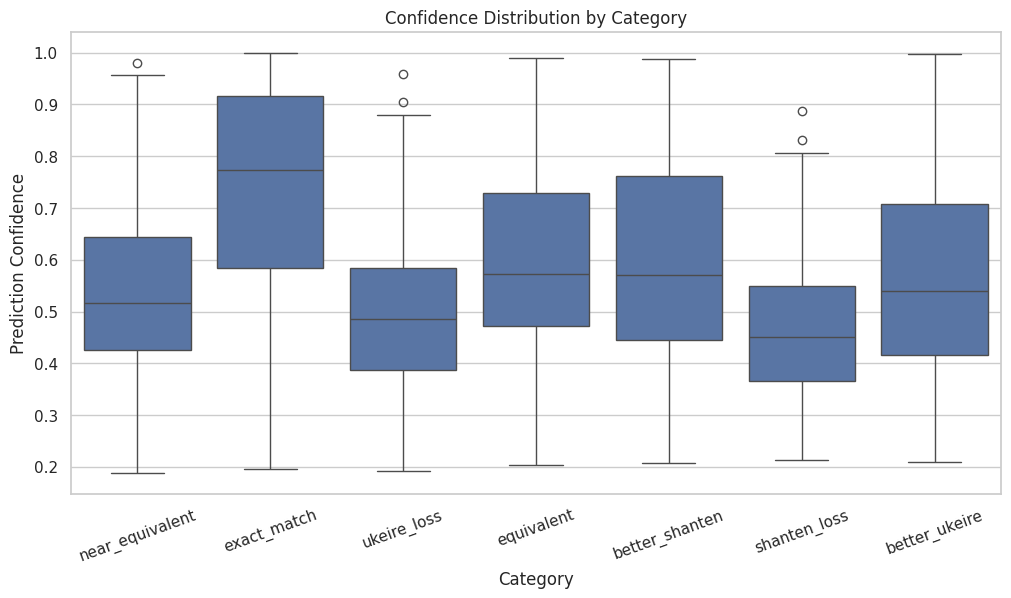

In [96]:
plt.figure(figsize=(12, 6))

sns.boxplot(

    data=results_df,

    x="category",

    y="model_prob",
)

plt.xticks(rotation=20)

plt.xlabel("Category")

plt.ylabel("Prediction Confidence")

plt.title(
    "Confidence Distribution by Category"
)

plt.show()

In [97]:
plt.savefig(

    "../reports/figures/500k/category_confidence_distribution_500k.png",

    dpi=300,

    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>

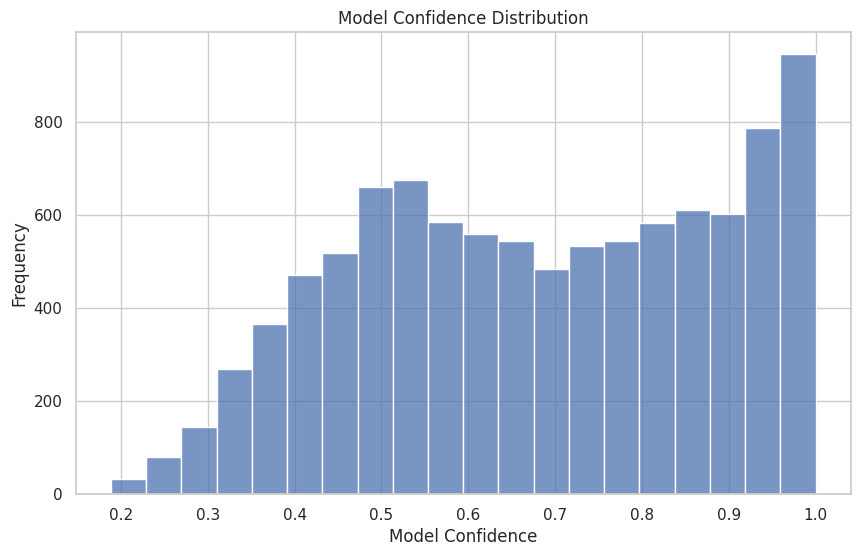

In [98]:
plt.figure(figsize=(10, 6))

sns.histplot(

    results_df["model_prob"],

    bins=20,
)

plt.xlabel(
    "Model Confidence"
)

plt.ylabel("Frequency")

plt.title(
    "Model Confidence Distribution"
)

plt.show()

In [99]:
plt.savefig(

    "../reports/figures/500k/confidence_distribution_500k.png",

    dpi=300,

    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>

In [115]:
results_df.to_csv(

    "../reports/tables/500k_results.csv",

    index=False,
)

In [116]:
distribution.to_csv(

    "../reports/tables/500k_distribution.csv"
)

In [117]:
summary = pd.DataFrame({

    "metric": [

        "exact_accuracy",

        "strategic_accuracy",

        "mean_confidence",

        "mean_ukeire_difference",
    ],

    "value": [

        results_df["same_action"].mean(),

        results_df["category"].isin([

            "exact_match",

            "equivalent",

            "near_equivalent",

            "better_ukeire",

            "better_shanten",

        ]).mean(),

        results_df["model_prob"].mean(),

        results_df["ukeire_difference"].mean(),
    ]
})

In [118]:
summary.to_csv(

    "../reports/tables/500k_summary.csv",

    index=False,
)

# Case Studies

Aggregate metrics provide a high-level overview of model performance, but they do not explain the nature of individual decisions.

This section presents representative examples from each strategic category:

- Exact Match
- Near Equivalent
- Better Ukeire
- Shanten Loss

For each example we inspect:

- The full Mahjong state
- The expert discard
- The model discard
- Shanten values
- Effective ukeire values

This allows qualitative analysis of the model's strategic behavior.

In [100]:
def load_state(offset):

    query = f"""
    SELECT Data
    FROM Discard
    LIMIT 1 OFFSET {offset}
    """

    row = conn.execute(
        query
    ).fetchone()

    decoded = json.loads(
        gzip.decompress(
            row[0]
        )
    )

    canonical_state = {

        "round_wind":
            decoded["round_wind"],

        "num_honba":
            decoded["num_honba"],

        "num_riichi":
            decoded["num_riichi"],

        "player_wind":
            decoded["player_wind"],

        "position":
            decoded["position"],

        "remain_tiles":
            decoded["remain_tiles"],

        "dora_indicators":
            decoded["dora_indicators"],

        "hand_tiles":
            decoded["hand_tiles"],

        "players": {

            "0": decoded["0"],
            "1": decoded["1"],
            "2": decoded["2"],
            "3": decoded["3"],
        },

        "valid_actions":
            decoded["valid_actions"],

        "action_idx":
            decoded["action_idx"],
    }

    return canonical_state

In [101]:
from src.utils.state_renderer import (
    render_state
)

## Case Study 1 — Exact Match

This example shows a state where the transformer selects the same discard as the expert player.

In [102]:
exact_case = results_df[

    results_df["category"]
    ==
    "exact_match"

].sample(1)

exact_case

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
3285,1m,1m,True,2,2,20,20,0,0,0.909204,exact_match,3286.0


In [103]:
state = load_state(

    int(
        exact_case.iloc[0]["offset"]
    ) - 1
)

render_state(state)


ROUND

Round Wind: 1
Honba: 2
Riichi Sticks: 1
Remaining Tiles: 43

Dora Indicators: east

PLAYER 0

Points: 37200
Riichi: False
MELDS:
pon: ['1s', '1s', '1s']

DISCARDS:
south 9p 6m* 5p west* 7p* 2m* 7m

PLAYER 1

Points: 22700
Riichi: False

HAND:
5m 6m 7m 1p 3p 6p 6p 7p 4s 5s north north white 1m

MELDS:
None

DISCARDS:
9p 1m green* red 9m 2s 1s

PLAYER 2

Points: 20400
Riichi: False
MELDS:
None

DISCARDS:
green north 9s 2s 1p* 9m

PLAYER 3

Points: 18700
Riichi: False
MELDS:
None

DISCARDS:
south west red 8p 8p* 7s


In [104]:
exact_case.T

,3285
expert_tile,1m
model_tile,1m
same_action,True
expert_shanten,2
model_shanten,2
expert_ukeire,20
model_ukeire,20
shanten_difference,0
ukeire_difference,0
model_prob,0.909204


### Discussion

The model reproduces the expert action exactly.

This suggests that the learned policy captures the same local strategic considerations as the expert in this situation.

## Case Study 2 — Near Equivalent

This example shows a disagreement between the model and the expert.

However, the resulting hand quality remains strategically similar.

In [105]:
near_case = results_df[

    results_df["category"]
    ==
    "near_equivalent"

].sample(1)

near_case

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
7259,7m,2m,False,1,1,16,14,0,2,0.431339,near_equivalent,7260.0


In [106]:
state = load_state(

    int(
        near_case.iloc[0]["offset"]
    ) - 1
)

render_state(state)


ROUND

Round Wind: 0
Honba: 2
Riichi Sticks: 0
Remaining Tiles: 20

Dora Indicators: 2p

PLAYER 0

Points: 30800
Riichi: False

HAND:
2m 3m 6m 7m 7m 6p 6p 6p 8p 8p 5s 5s 5s 3m

MELDS:
None

DISCARDS:
9m white* north* east 2s 8s* 9p 2p 3s red 3s* white*

PLAYER 1

Points: 24400
Riichi: False
MELDS:
pon: ['green', 'green', 'green']

DISCARDS:
9m 9p west 2m north red* 4m* 2m* 7s south 6s 2p 1p*

PLAYER 2

Points: 22400
Riichi: False
MELDS:
None

DISCARDS:
north south 1m 9p 5s 9s east* green* 1p* 9p 1s 4m white*

PLAYER 3

Points: 22400
Riichi: False
MELDS:
None

DISCARDS:
east 1s 9s 1m north red 9m* 7p 1s* 1s* white* 1p


In [107]:
near_case.T

,7259
expert_tile,7m
model_tile,2m
same_action,False
expert_shanten,1
model_shanten,1
expert_ukeire,16
model_ukeire,14
shanten_difference,0
ukeire_difference,2
model_prob,0.431339


### Discussion

The transformer chooses a different discard from the expert.

Despite this disagreement, both actions preserve hand efficiency and result in similar strategic outcomes.

## Case Study 3 — Better Ukeire

This example shows a situation where the model chooses a discard that results in a larger effective ukeire than the expert action.

In [108]:
better_case = results_df[

    results_df["category"]
    ==
    "better_ukeire"

].sort_values(

    by="ukeire_difference",

    ascending=True,
)

better_case.head(1)

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
8208,9p,green,False,5,5,30,80,0,-50,0.271678,better_ukeire,8209.0


In [109]:
state = load_state(

    int(
        better_case.iloc[0]["offset"]
    ) - 1
)

render_state(state)


ROUND

Round Wind: 0
Honba: 0
Riichi Sticks: 0
Remaining Tiles: 58

Dora Indicators: 9p

PLAYER 0

Points: 24700
Riichi: False
MELDS:
None

DISCARDS:
south west 9m

PLAYER 1

Points: 26100
Riichi: False
MELDS:
None

DISCARDS:
9s 2m* north

PLAYER 2

Points: 24700
Riichi: False
MELDS:
None

DISCARDS:
north green 4s

PLAYER 3

Points: 24500
Riichi: False

HAND:
2m 5m 8m 9m 1p 8p 8p 9p 5s 8s white green red 6p

MELDS:
None

DISCARDS:
south west


In [110]:
better_case.head(1).T

,8208
expert_tile,9p
model_tile,green
same_action,False
expert_shanten,5
model_shanten,5
expert_ukeire,30
model_ukeire,80
shanten_difference,0
ukeire_difference,-50
model_prob,0.271678


### Discussion

The model selects a discard that increases effective ukeire while preserving shanten.

This does not necessarily imply that the model found a superior Mahjong decision, since defensive considerations, hand value, and game context are not captured by the evaluation metrics.

However, it demonstrates that expert imitation and efficiency optimization are not always identical.

## Case Study 4 — Shanten Loss

This example illustrates a genuine strategic mistake.

The model chooses a discard that worsens the hand's shanten number compared to the expert action.

In [111]:
bad_case = results_df[

    results_df["category"]
    ==
    "shanten_loss"

].head(1)

bad_case

,expert_tile,model_tile,same_action,expert_shanten,model_shanten,expert_ukeire,model_ukeire,shanten_difference,ukeire_difference,model_prob,category,offset
44,5s,7p,False,0,1,3,20,-1,-17,0.509765,shanten_loss,45.0


In [112]:
state = load_state(

    int(
        bad_case.iloc[0]["offset"]
    ) - 1
)

render_state(state)


ROUND

Round Wind: 0
Honba: 0
Riichi Sticks: 0
Remaining Tiles: 3

Dora Indicators: west green

PLAYER 0

Points: 22500
Riichi: True
MELDS:
ankan: ['3s', '3s', '3s', '3s']

DISCARDS:
1p 1s red 8s 8p 5p 9s* 5s* 2p* 1s* 2p* 8m* 2s* 5m* 7s* green* 7p*

PLAYER 1

Points: 32700
Riichi: False
MELDS:
None

DISCARDS:
east red east* 8s 9s* 8s* north* south* 1p 4s 8p north* 8m 2s 2s 2s* 8p*

PLAYER 2

Points: 19800
Riichi: False

HAND:
1m 1m 3m 4m 5m 5p 7p 4s 5s 6s 5s

MELDS:
chi: ['6m', '7m', '8m']

DISCARDS:
1s 9m west* 7p 4s 7m* 4p 1s south* 9p* 9s 1p 1p 8s 5p south*

PLAYER 3

Points: 25000
Riichi: False
MELDS:
None

DISCARDS:
south west 9p east white red north 9s* 6p green* 2p 8m 2p east* 7s 7s


In [113]:
bad_case.T

,44
expert_tile,5s
model_tile,7p
same_action,False
expert_shanten,0
model_shanten,1
expert_ukeire,3
model_ukeire,20
shanten_difference,-1
ukeire_difference,-17
model_prob,0.509765


### Discussion

Unlike previous examples, the model's action directly worsens hand progression.

These cases represent true strategic failures and provide insight into the remaining weaknesses of the learned policy.

# Case Study Summary

The qualitative examples support the quantitative findings presented earlier.

Several disagreements between the model and expert players correspond to strategically equivalent alternatives rather than genuine mistakes.

Furthermore, some model decisions produce higher effective ukeire than the expert action, suggesting that exact imitation accuracy alone is insufficient to characterize Mahjong policy quality.

The most informative failures are the shanten loss cases, which represent situations where the model genuinely degrades hand efficiency.